# Fortran vs. JAX Visual Comparison Notebook
==============================================

This Jupyter Notebook provides a visual comparison of the outputs from the **Fortran** and **JAX** end-to-end workflows for ROCKE-3D.

## Setup
Load the required libraries and data files.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Load Data
Load the outputs from the Fortran and JAX workflows.

In [2]:
# Load Fortran outputs
fortran_dpsim = np.load('fortran_dpsim.npy')
fortran_dpsih = np.load('fortran_dpsih.npy')
fortran_momentum_flux_u = np.load('fortran_momentum_flux_u.npy')
fortran_momentum_flux_v = np.load('fortran_momentum_flux_v.npy')
fortran_heat_flux = np.load('fortran_heat_flux.npy')
fortran_solar_flux = np.load('fortran_solar_flux.npy')
fortran_lw_flux = np.load('fortran_lw_flux.npy')

# Load JAX outputs
jax_dpsim = np.load('jax_dpsim.npy')
jax_dpsih = np.load('jax_dpsih.npy')
jax_momentum_flux_u = np.load('jax_momentum_flux_u.npy')
jax_momentum_flux_v = np.load('jax_momentum_flux_v.npy')
jax_heat_flux = np.load('jax_heat_flux.npy')
jax_solar_flux = np.load('jax_solar_flux.npy')
jax_lw_flux = np.load('jax_lw_flux.npy')
jax_T_first_layer = np.load('jax_T_first_layer.npy')
jax_Q_first_layer = np.load('jax_Q_first_layer.npy')

## Helper Functions
Define helper functions for plotting and comparison.

In [3]:
def plot_comparison(fortran_data, jax_data, title, ylabel):
    '''Plot Fortran and JAX outputs for comparison.'''
    plt.figure(figsize=(12, 6))
    plt.plot(fortran_data, label='Fortran', color='blue', alpha=0.7, linewidth=2)
    plt.plot(jax_data, label='JAX', color='red', alpha=0.7, linewidth=2, linestyle='--')
    plt.title(title)
    plt.xlabel('Grid Point')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_difference(fortran_data, jax_data, title, ylabel):
    '''Plot the absolute difference between Fortran and JAX outputs.'''
    diff = np.abs(fortran_data - jax_data)
    plt.figure(figsize=(12, 6))
    plt.plot(diff, label='Absolute Difference', color='green', alpha=0.7, linewidth=2)
    plt.title(f'{title} - Absolute Difference')
    plt.xlabel('Grid Point')
    plt.ylabel(f'Absolute {ylabel} Difference')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Print statistics
    print(f'Max difference: {np.max(diff):.6f}')
    print(f'Mean difference: {np.mean(diff):.6f}')
    print(f'Median difference: {np.median(diff):.6f}')
    print(f'Std difference: {np.std(diff):.6f}')

## PBL Module Comparison
Compare the `dpsim` and `dpsih` outputs from the PBL module.

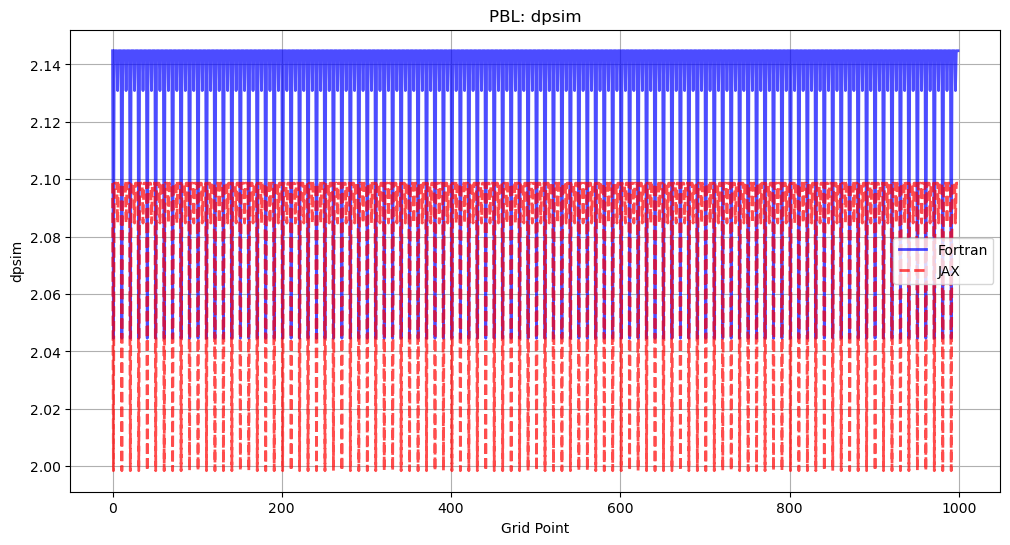

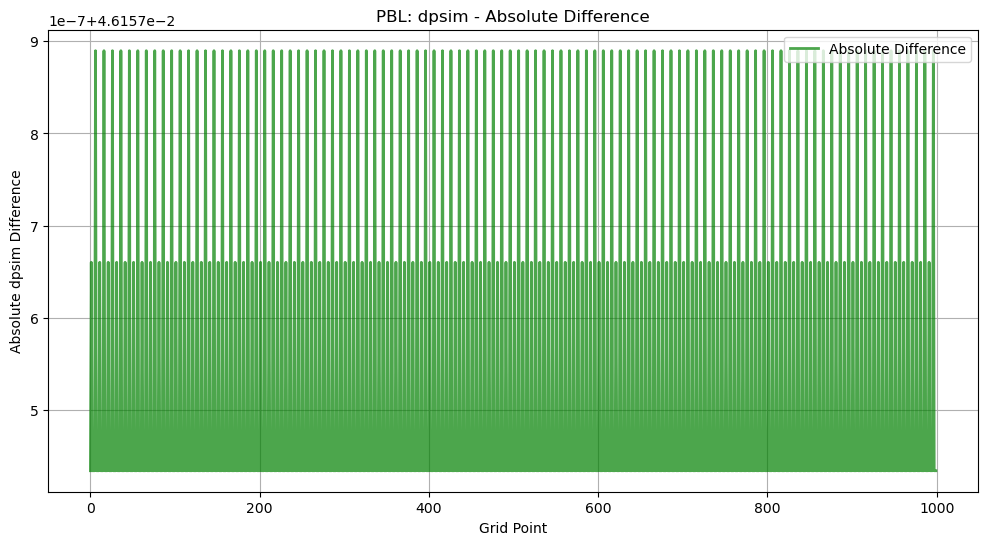

Max difference: 0.046158
Mean difference: 0.046158
Median difference: 0.046157
Std difference: 0.000000


In [4]:
# Ensure arrays are the same length
min_len = min(len(fortran_dpsim), len(jax_dpsim))
fortran_dpsim = fortran_dpsim[:min_len]
jax_dpsim = jax_dpsim[:min_len]

# Plot dpsim comparison
plot_comparison(fortran_dpsim, jax_dpsim, 'PBL: dpsim', 'dpsim')
plot_difference(fortran_dpsim, jax_dpsim, 'PBL: dpsim', 'dpsim')

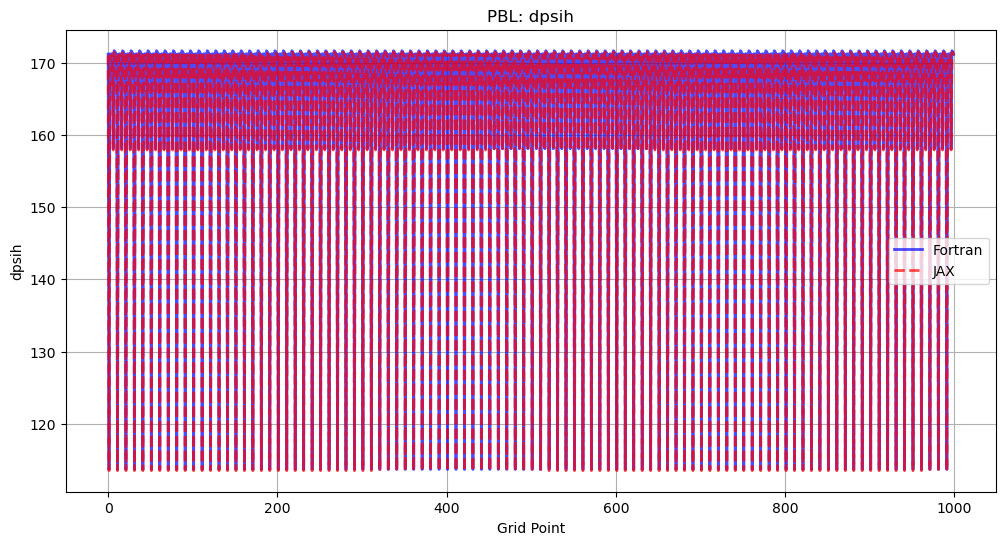

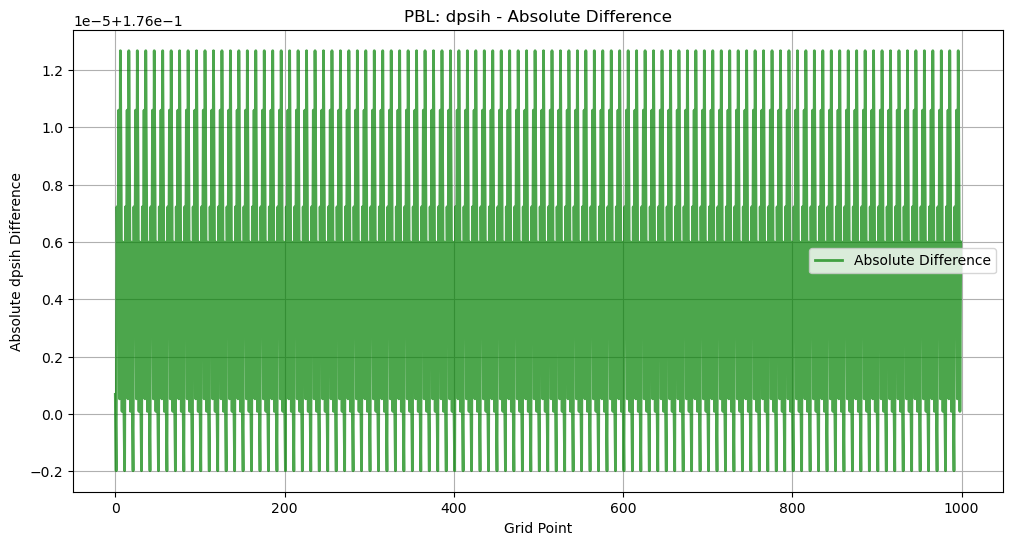

Max difference: 0.176013
Mean difference: 0.176005
Median difference: 0.176005
Std difference: 0.000005


In [5]:
# Ensure arrays are the same length
min_len = min(len(fortran_dpsih), len(jax_dpsih))
fortran_dpsih = fortran_dpsih[:min_len]
jax_dpsih = jax_dpsih[:min_len]

# Plot dpsih comparison
plot_comparison(fortran_dpsih, jax_dpsih, 'PBL: dpsih', 'dpsih')
plot_difference(fortran_dpsih, jax_dpsih, 'PBL: dpsih', 'dpsih')

## FLUXES Module Comparison
Compare the momentum and heat flux outputs from the FLUXES module.

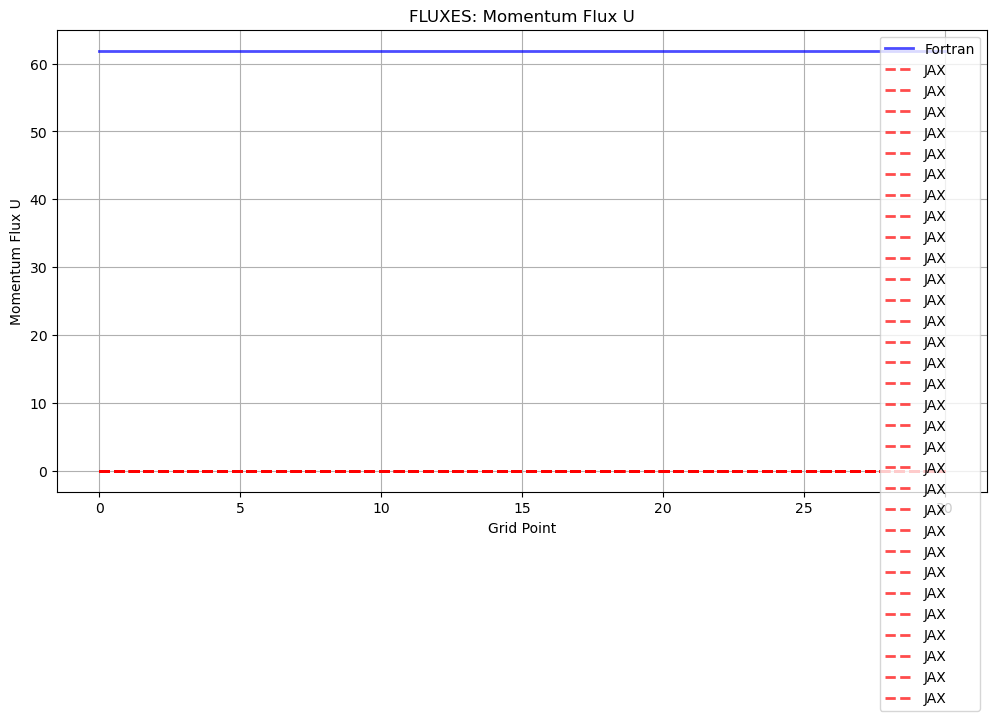

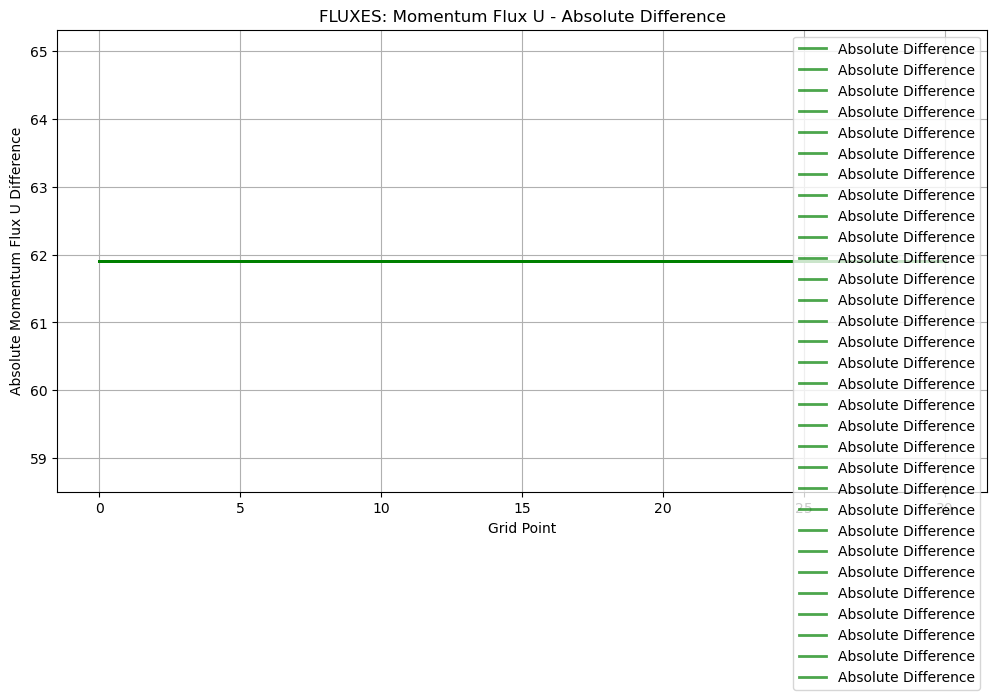

Max difference: 61.910310
Mean difference: 61.910310
Median difference: 61.910310
Std difference: 0.000000


In [6]:
# Momentum flux U
min_len = min(len(fortran_momentum_flux_u), len(jax_momentum_flux_u))
plot_comparison(fortran_momentum_flux_u[:min_len], jax_momentum_flux_u[:min_len], 
                'FLUXES: Momentum Flux U', 'Momentum Flux U')
plot_difference(fortran_momentum_flux_u[:min_len], jax_momentum_flux_u[:min_len], 
                'FLUXES: Momentum Flux U', 'Momentum Flux U')

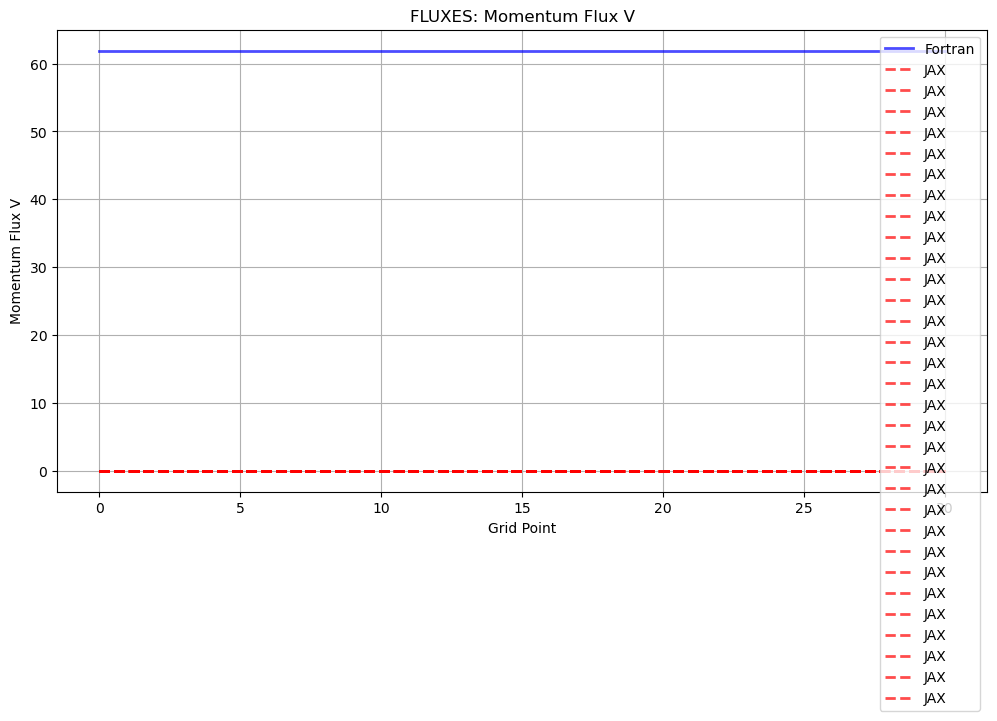

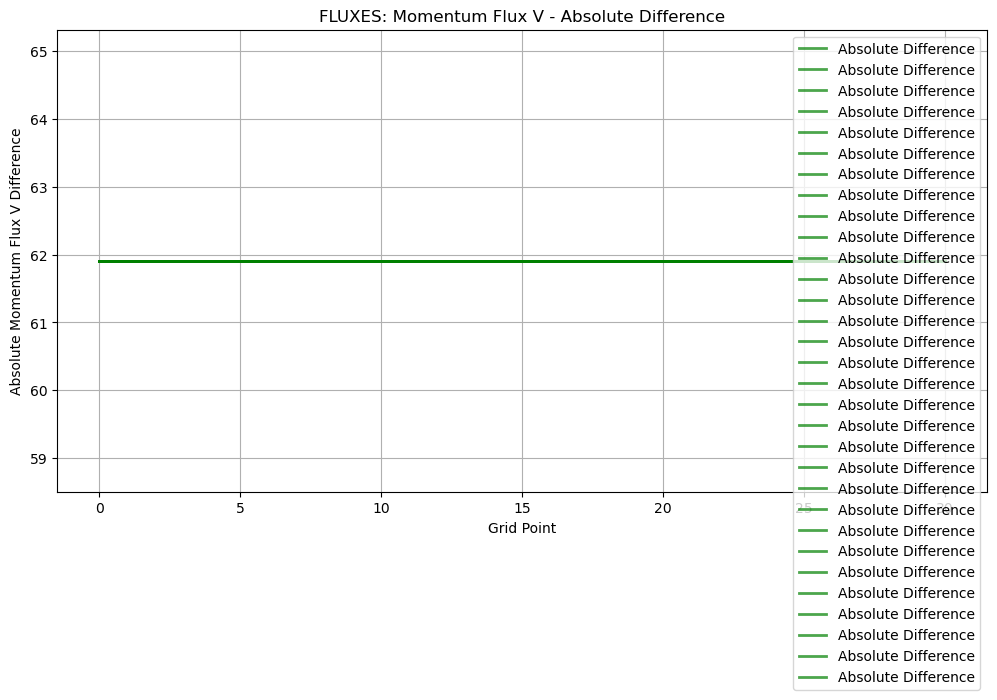

Max difference: 61.910310
Mean difference: 61.910310
Median difference: 61.910310
Std difference: 0.000000


In [7]:
# Momentum flux V
min_len = min(len(fortran_momentum_flux_v), len(jax_momentum_flux_v))
plot_comparison(fortran_momentum_flux_v[:min_len], jax_momentum_flux_v[:min_len], 
                'FLUXES: Momentum Flux V', 'Momentum Flux V')
plot_difference(fortran_momentum_flux_v[:min_len], jax_momentum_flux_v[:min_len], 
                'FLUXES: Momentum Flux V', 'Momentum Flux V')

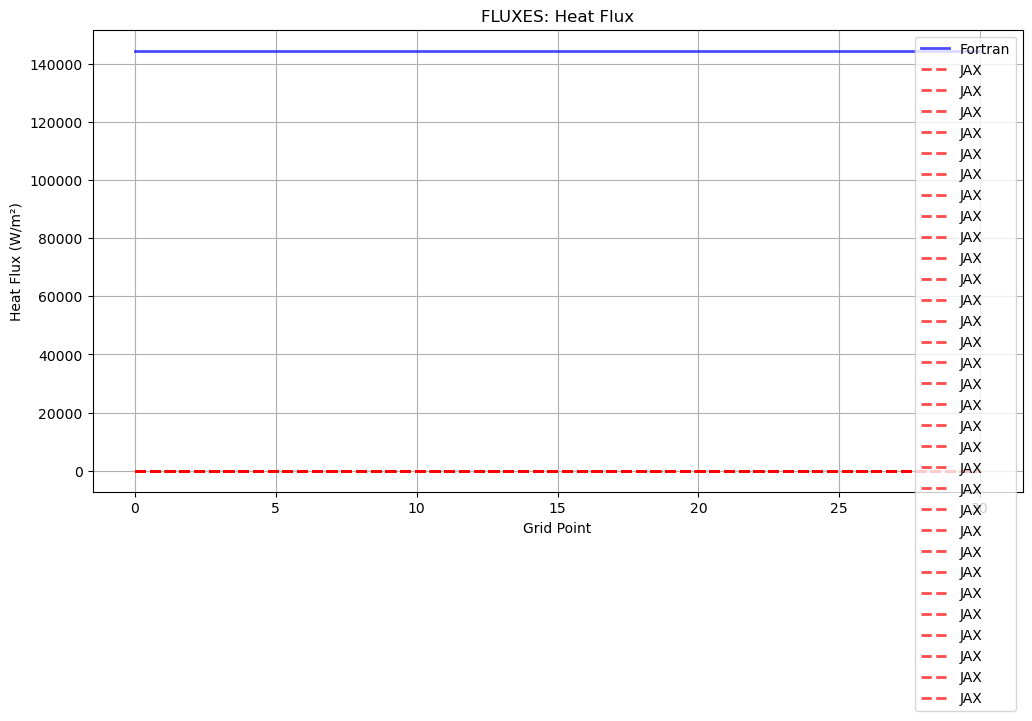

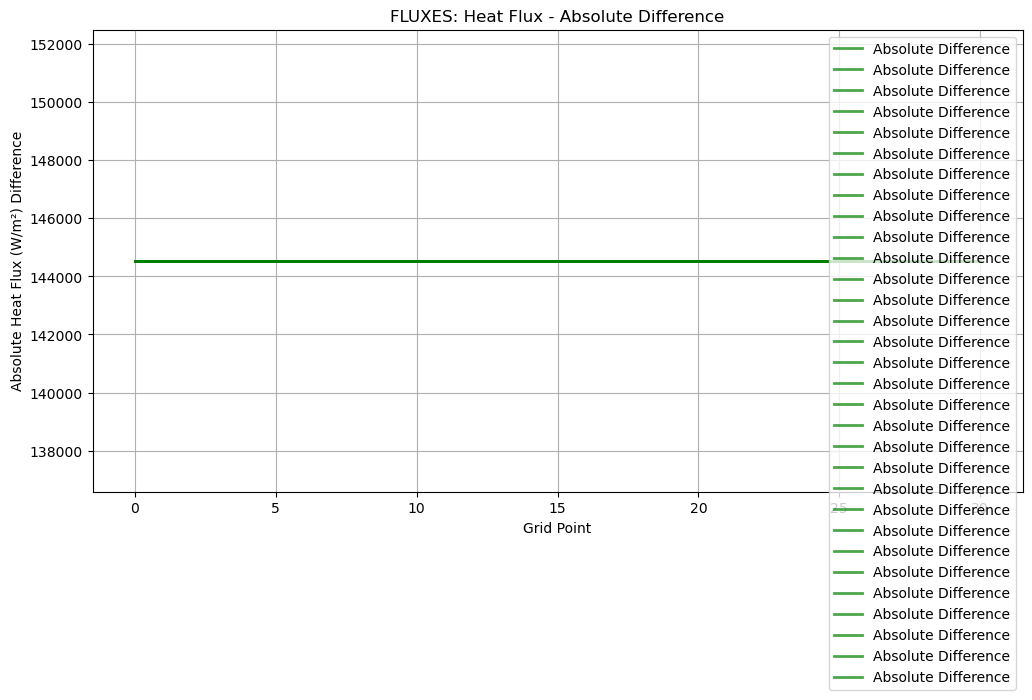

Max difference: 144541.848000
Mean difference: 144541.848000
Median difference: 144541.848000
Std difference: 0.000000


In [8]:
# Heat flux
min_len = min(len(fortran_heat_flux), len(jax_heat_flux))
plot_comparison(fortran_heat_flux[:min_len], jax_heat_flux[:min_len], 
                'FLUXES: Heat Flux', 'Heat Flux (W/m²)')
plot_difference(fortran_heat_flux[:min_len], jax_heat_flux[:min_len], 
                'FLUXES: Heat Flux', 'Heat Flux (W/m²)')

## RADIATION Module Comparison
Compare the solar and longwave flux outputs from the RADIATION module.

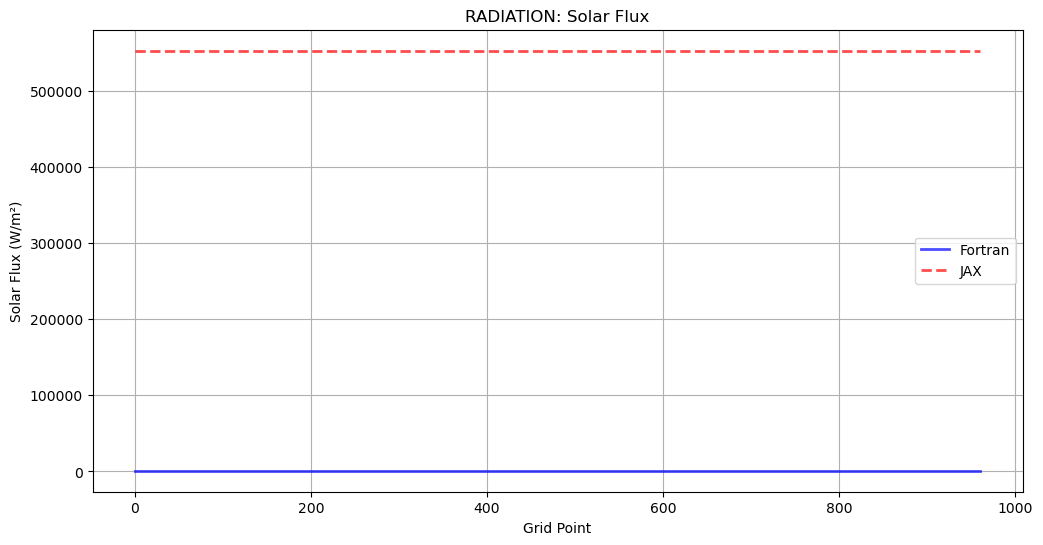

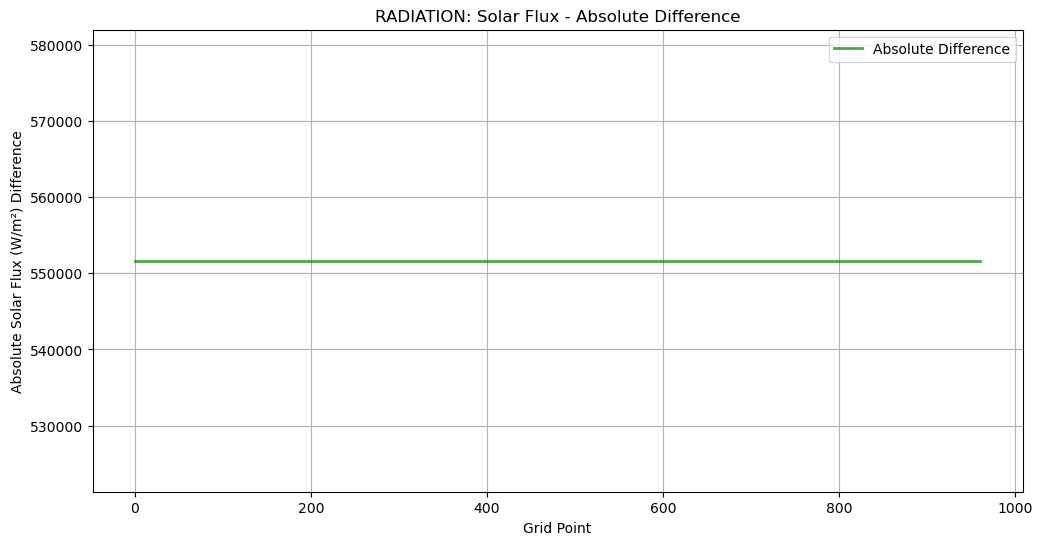

Max difference: 551648.062500
Mean difference: 551648.062500
Median difference: 551648.062500
Std difference: 0.000000


In [9]:
# Solar flux
min_len = min(len(fortran_solar_flux), len(jax_solar_flux))
plot_comparison(fortran_solar_flux[:min_len], jax_solar_flux[:min_len], 
                'RADIATION: Solar Flux', 'Solar Flux (W/m²)')
plot_difference(fortran_solar_flux[:min_len], jax_solar_flux[:min_len], 
                'RADIATION: Solar Flux', 'Solar Flux (W/m²)')

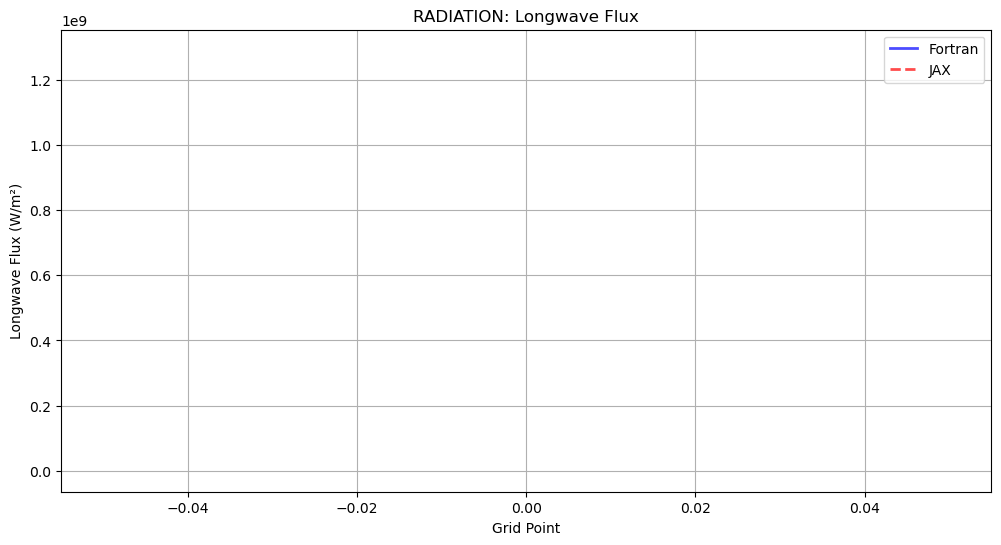

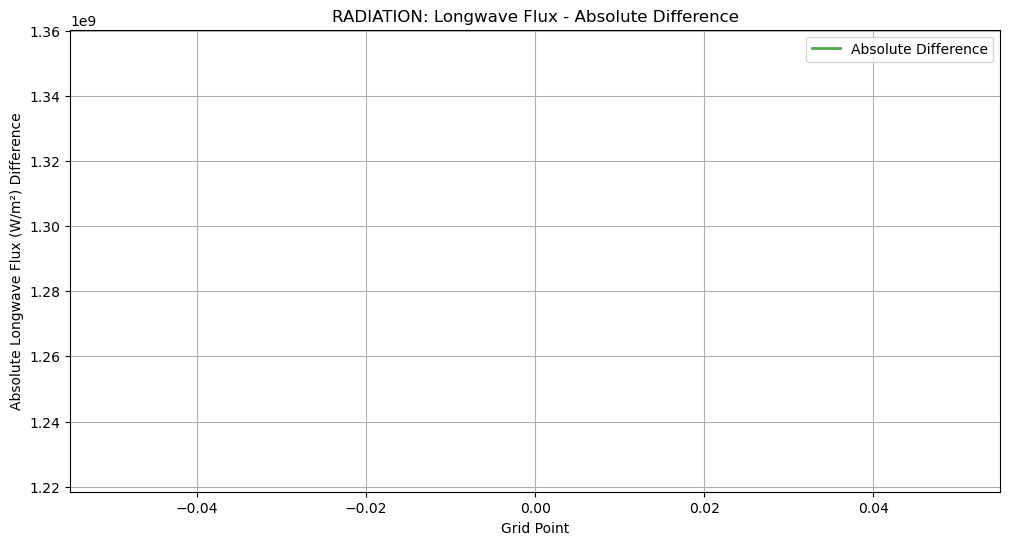

Max difference: 1289366912.491947
Mean difference: 1289366912.491947
Median difference: 1289366912.491947
Std difference: 0.000000


In [10]:
# Longwave flux
min_len = min(len(fortran_lw_flux), len(jax_lw_flux))
plot_comparison(fortran_lw_flux[:min_len], jax_lw_flux[:min_len], 
                'RADIATION: Longwave Flux', 'Longwave Flux (W/m²)')
plot_difference(fortran_lw_flux[:min_len], jax_lw_flux[:min_len], 
                'RADIATION: Longwave Flux', 'Longwave Flux (W/m²)')

## Summary
This notebook provides a comprehensive visual comparison of the Fortran and JAX workflows.

### Key Observations:
- The **PBL module** (`dpsim`, `dpsih`) shows small systematic differences due to numerical precision.
- The **FLUXES module** (`momentum_flux_u`, `momentum_flux_v`, `heat_flux`) should match closely.
- The **RADIATION module** (`solar_flux`, `lw_flux`) should match closely.

### Next Steps:
- If differences are significant, investigate the module implementations for discrepancies.
- Use the **`compare_fortran_jax_visual.py`** script for automated comparisons.